# 🤗 Transformers, Attention & Hugging Face
## Advanced Practical Implementation
**Course:** Artificial Intelligence / Deep Learning  
**Total Marks:** 25  

---

## 📦 Install & Import Libraries

In [1]:
!pip install -q transformers datasets scikit-learn torch seaborn matplotlib pandas numpy accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import math
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from datasets import Dataset, load_dataset
import evaluate

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix
)
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Device        : {device}")
print(f"🔥 PyTorch       : {torch.__version__}")
print("✅ All libraries imported successfully!")

🔧 Device        : cpu
🔥 PyTorch       : 2.10.0+cpu
✅ All libraries imported successfully!


---
## PART A – Implement Self-Attention from Scratch (5 Marks)
---

In [3]:
# ── Step 1: Create Random Embeddings ──
torch.manual_seed(42)

batch_size = 2
seq_len    = 5
d_model    = 16

# Random input embeddings: shape (batch, seq_len, d_model)
X = torch.randn(batch_size, seq_len, d_model)

print("=" * 55)
print("  STEP 1: Input Embeddings")
print("=" * 55)
print(f"  batch_size : {batch_size}")
print(f"  seq_len    : {seq_len}")
print(f"  d_model    : {d_model}")
print(f"  X shape    : {X.shape}  → (batch, seq_len, d_model)")
print(f"\n  X[0] (first batch sample):")
print(X[0].numpy().round(4))

  STEP 1: Input Embeddings
  batch_size : 2
  seq_len    : 5
  d_model    : 16
  X shape    : torch.Size([2, 5, 16])  → (batch, seq_len, d_model)

  X[0] (first batch sample):
[[ 1.9269  1.4873  0.9007 -2.1055  0.6784 -1.2345 -0.0431 -1.6047 -0.7521
   1.6487 -0.3925 -1.4036 -0.7279 -0.5594 -0.7688  0.7624]
 [ 1.6423 -0.1596 -0.4974  0.4396 -0.7581  1.0783  0.8008  1.6806  1.2791
   1.2964  0.6105  1.3347 -0.2316  0.0418 -0.2516  0.8599]
 [-1.3847 -0.8712 -0.2234  1.7174  0.3189 -0.4245  0.3057 -0.7746 -1.5576
   0.9956 -0.8798 -0.6011 -1.2742  2.1228 -1.2347 -0.4879]
 [-0.9138 -0.6581  0.078   0.5258 -0.488   1.1914 -0.814  -0.736  -1.4032
   0.036  -0.0635  0.6756 -0.0978  1.8446 -1.1845  1.3835]
 [ 1.4451  0.8564  2.2181  0.5232  0.3466 -0.1973 -1.0546  1.278  -0.1722
   0.5238  0.0566  0.4263  0.575  -0.6417 -2.2064 -0.7508]]


In [4]:
# ── Step 2: Compute Query, Key, Value Matrices Manually ──
torch.manual_seed(0)

d_k = d_model  # key/query dimension
d_v = d_model  # value dimension

# Weight matrices (learnable in real models)
W_Q = torch.randn(d_model, d_k)
W_K = torch.randn(d_model, d_k)
W_V = torch.randn(d_model, d_v)

# Compute Q, K, V  →  shape: (batch, seq_len, d_k)
Q = X @ W_Q   # Query
K = X @ W_K   # Key
V = X @ W_V   # Value

print("=" * 55)
print("  STEP 2: Query, Key, Value Matrices")
print("=" * 55)
print(f"  W_Q shape : {W_Q.shape}")
print(f"  W_K shape : {W_K.shape}")
print(f"  W_V shape : {W_V.shape}")
print(f"\n  Q shape   : {Q.shape}  → (batch, seq_len, d_k)")
print(f"  K shape   : {K.shape}  → (batch, seq_len, d_k)")
print(f"  V shape   : {V.shape}  → (batch, seq_len, d_v)")
print(f"\n  Q[0] (first batch):")
print(Q[0].detach().numpy().round(4))

  STEP 2: Query, Key, Value Matrices
  W_Q shape : torch.Size([16, 16])
  W_K shape : torch.Size([16, 16])
  W_V shape : torch.Size([16, 16])

  Q shape   : torch.Size([2, 5, 16])  → (batch, seq_len, d_k)
  K shape   : torch.Size([2, 5, 16])  → (batch, seq_len, d_k)
  V shape   : torch.Size([2, 5, 16])  → (batch, seq_len, d_v)

  Q[0] (first batch):
[[ -4.4682  -4.3975   1.7414   1.2623  -0.1737   0.2281  -4.9634  -0.0936
    4.117   -5.7858  -7.6705  -7.0693   3.8179  12.9993  -0.4615   0.2757]
 [ -2.3128  -9.8823  -4.0358  -0.8872   6.9218  -1.4406   4.6157  -4.0946
   -0.6745  -0.2169   2.7095   0.3889  -1.7142  -3.2286   5.0587   1.2855]
 [  6.8995   6.3387   6.0704   2.68   -10.1595   0.1609  -3.8957  -1.1548
    1.3124   6.1549  -1.8509   6.7666  -3.3556  -2.3048  -3.6863   3.4685]
 [  2.2064   2.1499   0.2845  -2.4548   1.5426  -0.106    1.6996   1.4673
    0.9441   9.1352  -0.7513   2.7255  -2.0755  -4.3594  -3.1337   1.9718]
 [ -5.8564  -6.0645  -1.57     0.5664   6.6062   1.6

In [5]:
# ── Step 3: Attention Scores = QK^T / sqrt(d_k) ──
scaling_factor = math.sqrt(d_k)

# QK^T  →  shape: (batch, seq_len, seq_len)
scores = torch.matmul(Q, K.transpose(-2, -1)) / scaling_factor

print("=" * 55)
print("  STEP 3: Attention Scores  QKᵀ / √d_k")
print("=" * 55)
print(f"  Scaling factor  : √{d_k} = {scaling_factor:.4f}")
print(f"  Scores shape    : {scores.shape}  → (batch, seq_len, seq_len)")
print(f"\n  Raw scores [batch 0]:")
print(scores[0].detach().numpy().round(4))

print("""
  📌 Why do we scale by √d_k?
  When d_k is large, dot products grow very large in magnitude.
  This pushes softmax into regions with extremely small gradients,
  making training unstable. Dividing by √d_k keeps the scores
  in a reasonable range so softmax works properly.
""")

  STEP 3: Attention Scores  QKᵀ / √d_k
  Scaling factor  : √16 = 4.0000
  Scores shape    : torch.Size([2, 5, 5])  → (batch, seq_len, seq_len)

  Raw scores [batch 0]:
[[-54.585   -2.326   10.6944  20.3701 -26.7554]
 [ 43.1549  -4.0847  19.0535  -4.364    9.6699]
 [ 13.3838  -5.4717 -25.4217 -28.585    9.0116]
 [ 18.1364   5.6075 -22.6569 -23.6391   5.6262]
 [-19.4653 -31.4197   6.6926 -14.5459 -10.036 ]]

  📌 Why do we scale by √d_k?
  When d_k is large, dot products grow very large in magnitude.
  This pushes softmax into regions with extremely small gradients,
  making training unstable. Dividing by √d_k keeps the scores
  in a reasonable range so softmax works properly.



In [6]:
# ── Step 4: Softmax + Weighted Sum Output ──
# Apply softmax along last dimension (over seq_len keys)
attention_weights = F.softmax(scores, dim=-1)

# Weighted sum of values
output = torch.matmul(attention_weights, V)

print("=" * 55)
print("  STEP 4: Softmax & Weighted Sum")
print("=" * 55)
print(f"  Attention weights shape : {attention_weights.shape}")
print(f"  Output shape            : {output.shape}")
print(f"\n  Attention Weights [batch 0]:")
print(attention_weights[0].detach().numpy().round(4))
print(f"\n  Row sums (should all = 1.0): {attention_weights[0].sum(dim=-1).detach().numpy().round(4)}")
print(f"\n  Self-Attention Output [batch 0]:")
print(output[0].detach().numpy().round(4))

print("""
  📌 Role of Softmax:
  Softmax converts raw attention scores into probabilities
  that sum to 1.0. Higher scores get higher weights, meaning
  the model pays more attention to those tokens. This creates
  a soft, differentiable selection mechanism.
""")

  STEP 4: Softmax & Weighted Sum
  Attention weights shape : torch.Size([2, 5, 5])
  Output shape            : torch.Size([2, 5, 16])

  Attention Weights [batch 0]:
[[0.000e+00 0.000e+00 1.000e-04 9.999e-01 0.000e+00]
 [1.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [9.875e-01 0.000e+00 0.000e+00 0.000e+00 1.250e-02]
 [1.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 1.000e+00 0.000e+00 0.000e+00]]

  Row sums (should all = 1.0): [1. 1. 1. 1. 1.]

  Self-Attention Output [batch 0]:
[[  0.9875   2.8496   1.688    7.3599  -2.3979  -4.2042  -1.524    1.2904
   -3.9611  -0.3281   7.1629  -4.1782  -0.604   -0.7874  -0.0364  -2.1253]
 [ -7.8199   4.7916  -5.4555   0.4662   1.3157  -1.7118   1.0865  -2.0362
    3.2577  -2.4915   8.3047  -3.1649  -1.2839  -2.0406  -1.5579   2.8973]
 [ -7.7023   4.7671  -5.4866   0.3814   1.2956  -1.7352   1.0965  -2.0332
    3.2533  -2.3667   8.1931  -3.1281  -1.2459  -2.0006  -1.5649   2.8536]
 [ -7.8198   4.7916  -5.4555   0.466

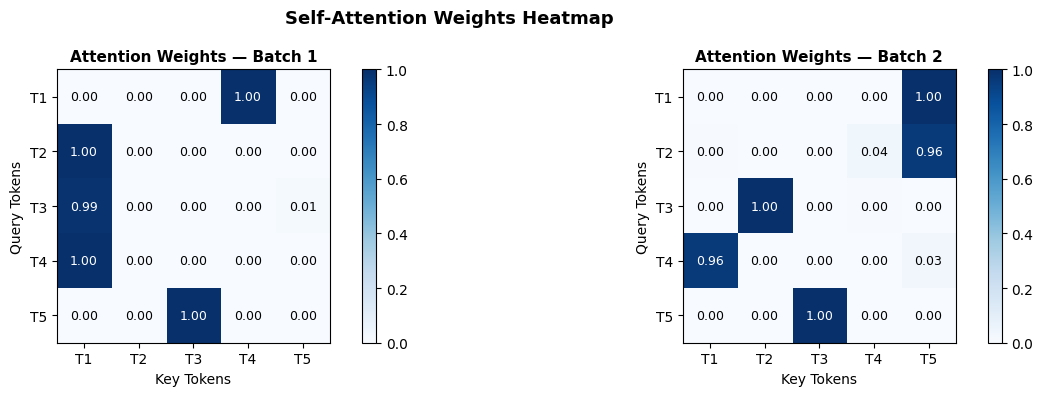

✅ Self-Attention implemented and visualized from scratch!


In [7]:
# ── Visualize Attention Weights ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

token_labels = [f'T{i+1}' for i in range(seq_len)]

for b, ax in enumerate(axes):
    weights = attention_weights[b].detach().numpy()
    im = ax.imshow(weights, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(seq_len)); ax.set_xticklabels(token_labels)
    ax.set_yticks(range(seq_len)); ax.set_yticklabels(token_labels)
    ax.set_title(f'Attention Weights — Batch {b+1}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Key Tokens');  ax.set_ylabel('Query Tokens')
    for i in range(seq_len):
        for j in range(seq_len):
            ax.text(j, i, f'{weights[i,j]:.2f}', ha='center', va='center',
                    fontsize=9, color='white' if weights[i,j] > 0.5 else 'black')
    plt.colorbar(im, ax=ax)

plt.suptitle('Self-Attention Weights Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('self_attention_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Self-Attention implemented and visualized from scratch!")

In [8]:
# ── Full Self-Attention as a Clean Class ──
class SelfAttention(nn.Module):
    """Scaled Dot-Product Self-Attention implemented from scratch."""
    def __init__(self, d_model):
        super().__init__()
        self.d_k = d_model
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)
        scores  = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        weights = F.softmax(scores, dim=-1)
        output  = torch.matmul(weights, V)
        return output, weights

attn = SelfAttention(d_model)
out, wts = attn(X)
print(f"✅ SelfAttention class test — Output: {out.shape}, Weights: {wts.shape}")

✅ SelfAttention class test — Output: torch.Size([2, 5, 16]), Weights: torch.Size([2, 5, 5])


---
## PART B – Hugging Face Pipelines (5 Marks)
---

In [9]:
# ── Pipeline 1: Sentiment Analysis ──
print("Loading sentiment-analysis pipeline...")
sentiment_pipe = pipeline('sentiment-analysis',
                          model='distilbert-base-uncased-finetuned-sst-2-english')

sentiment_inputs = [
    "This is the most amazing course I have ever taken!",
    "The project deadline is too tight and very stressful.",
    "The food was decent but nothing extraordinary."
]

sentiment_results = sentiment_pipe(sentiment_inputs)

print("\n" + "=" * 65)
print("  PIPELINE 1 — SENTIMENT ANALYSIS")
print("=" * 65)
for text, res in zip(sentiment_inputs, sentiment_results):
    emoji = '😊' if res['label'] == 'POSITIVE' else '😞'
    print(f"  Input  : {text}")
    print(f"  Result : {emoji} {res['label']}  |  Confidence: {res['score']*100:.2f}%")
    print()

Loading sentiment-analysis pipeline...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]


  PIPELINE 1 — SENTIMENT ANALYSIS
  Input  : This is the most amazing course I have ever taken!
  Result : 😊 POSITIVE  |  Confidence: 99.99%

  Input  : The project deadline is too tight and very stressful.
  Result : 😞 NEGATIVE  |  Confidence: 99.28%

  Input  : The food was decent but nothing extraordinary.
  Result : 😞 NEGATIVE  |  Confidence: 97.38%



In [10]:
# ── Pipeline 2: Zero-Shot Classification ──
print("Loading zero-shot-classification pipeline...")
zero_shot_pipe = pipeline('zero-shot-classification',
                          model='facebook/bart-large-mnli')

candidate_labels = ['technology', 'sports', 'politics', 'education', 'health']

zero_shot_inputs = [
    "The new iPhone features a revolutionary AI chip for on-device processing.",
    "The football team won the championship after an intense penalty shootout.",
    "Universities are adopting AI tools to personalize student learning experiences."
]

print("\n" + "=" * 65)
print("  PIPELINE 2 — ZERO-SHOT CLASSIFICATION")
print("=" * 65)
for text in zero_shot_inputs:
    result = zero_shot_pipe(text, candidate_labels=candidate_labels)
    top_label = result['labels'][0]
    top_score = result['scores'][0]
    print(f"  Input      : {text}")
    print(f"  Top Label  : {top_label.upper()}  |  Score: {top_score*100:.2f}%")
    print(f"  All Scores : ", end="")
    for lbl, scr in zip(result['labels'], result['scores']):
        print(f"{lbl}: {scr:.2f}", end="  ")
    print("\n")

Loading zero-shot-classification pipeline...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


  PIPELINE 2 — ZERO-SHOT CLASSIFICATION
  Input      : The new iPhone features a revolutionary AI chip for on-device processing.
  Top Label  : TECHNOLOGY  |  Score: 97.86%
  All Scores : technology: 0.98  health: 0.01  sports: 0.01  education: 0.00  politics: 0.00  

  Input      : The football team won the championship after an intense penalty shootout.
  Top Label  : SPORTS  |  Score: 99.43%
  All Scores : sports: 0.99  technology: 0.00  health: 0.00  education: 0.00  politics: 0.00  

  Input      : Universities are adopting AI tools to personalize student learning experiences.
  Top Label  : TECHNOLOGY  |  Score: 52.57%
  All Scores : technology: 0.53  education: 0.46  health: 0.01  sports: 0.00  politics: 0.00  



In [11]:
# ── Pipeline 3: Text Generation ──
print("Loading text-generation pipeline...")
gen_pipe = pipeline('text-generation', model='gpt2', max_new_tokens=40)

gen_inputs = [
    "Artificial intelligence is transforming the world by",
    "Deep learning models learn from data and",
    "The future of natural language processing will"
]

print("\n" + "=" * 65)
print("  PIPELINE 3 — TEXT GENERATION")
print("=" * 65)
for prompt in gen_inputs:
    result = gen_pipe(prompt, num_return_sequences=1, do_sample=False)
    generated = result[0]['generated_text']
    print(f"  Prompt    : {prompt}")
    print(f"  Generated : {generated}")
    print()

Loading text-generation pipeline...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...


  PIPELINE 3 — TEXT GENERATION


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Prompt    : Artificial intelligence is transforming the world by
  Generated : Artificial intelligence is transforming the world by creating new ways to interact with the world around us.

The world is changing, and we need to change it.

We need to change the way we interact with the world around us



Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Prompt    : Deep learning models learn from data and
  Generated : Deep learning models learn from data and then apply it to real-world problems.

The problem is that the models are not very good at predicting the future. They are not very good at predicting the future. They are not very

  Prompt    : The future of natural language processing will
  Generated : The future of natural language processing will be a matter of great importance to the future of computing.

The future of natural language processing will be a matter of great importance to the future of computing. The future of computing will be a



In [12]:
# ── Explain Encoder / Decoder / Encoder-Decoder ──
print("""
╔══════════════════════════════════════════════════════════════════════╗
║   ENCODER-ONLY vs DECODER-ONLY vs ENCODER-DECODER MODELS           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🔵 ENCODER-ONLY (e.g. BERT, DistilBERT, RoBERTa)                  ║
║     • Reads entire input sequence bidirectionally.                   ║
║     • Best for: Classification, NER, Q&A, Sentiment Analysis.       ║
║     • Attention: each token sees ALL other tokens.                  ║
║                                                                      ║
║  🟢 DECODER-ONLY (e.g. GPT-2, GPT-4, LLaMA)                       ║
║     • Generates text left-to-right autoregressively.                ║
║     • Best for: Text Generation, Chatbots, Code completion.         ║
║     • Attention: each token only sees PAST tokens (causal mask).    ║
║                                                                      ║
║  🔴 ENCODER-DECODER (e.g. T5, BART, mT5)                           ║
║     • Encoder reads input, Decoder generates output.                ║
║     • Best for: Translation, Summarization, Q&A generation.         ║
║     • Combines bidirectional encoding + autoregressive decoding.    ║
║                                                                      ║
║  Pipeline Used → Encoder-Only (DistilBERT) for sentiment            ║
║                  Encoder-Decoder (BART) for zero-shot               ║
║                  Decoder-Only (GPT-2) for text generation           ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║   ENCODER-ONLY vs DECODER-ONLY vs ENCODER-DECODER MODELS           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🔵 ENCODER-ONLY (e.g. BERT, DistilBERT, RoBERTa)                  ║
║     • Reads entire input sequence bidirectionally.                   ║
║     • Best for: Classification, NER, Q&A, Sentiment Analysis.       ║
║     • Attention: each token sees ALL other tokens.                  ║
║                                                                      ║
║  🟢 DECODER-ONLY (e.g. GPT-2, GPT-4, LLaMA)                       ║
║     • Generates text left-to-right autoregressively.                ║
║     • Best for: Text Generation, Chatbots, Code completion.         ║
║     • Attention: each token only sees PAST tokens (causal mask).    ║
║                                                               

---
## PART C – Tokenization & Model Inspection (5 Marks)
---

In [13]:
# ── Load AutoTokenizer & AutoModel ──
MODEL_NAME = 'distilbert-base-uncased'

print(f"Loading AutoTokenizer: {MODEL_NAME}")
auto_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Loading AutoModel    : {MODEL_NAME}")
auto_model = AutoModel.from_pretrained(MODEL_NAME, output_attentions=True)
auto_model.eval()

print(f"\n✅ Model and Tokenizer loaded!")
print(f"   Vocab size    : {auto_tokenizer.vocab_size:,}")
print(f"   Model layers  : {auto_model.config.num_hidden_layers}")
print(f"   Hidden size   : {auto_model.config.hidden_size}")
print(f"   Attn heads    : {auto_model.config.num_attention_heads}")

Loading AutoTokenizer: distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Loading AutoModel    : distilbert-base-uncased


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✅ Model and Tokenizer loaded!
   Vocab size    : 30,522
   Model layers  : 6
   Hidden size   : 768
   Attn heads    : 12


In [14]:
# ── Tokenize & Display input_ids and attention_mask ──
sample_text = "Transformers revolutionized natural language processing tasks."

encoded = auto_tokenizer(
    sample_text,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=20
)

input_ids   = encoded['input_ids']
attn_mask   = encoded['attention_mask']
tokens      = auto_tokenizer.convert_ids_to_tokens(input_ids[0])
decoded_back = auto_tokenizer.convert_ids_to_tokens(input_ids[0].tolist())

print("=" * 65)
print("  TOKENIZATION RESULTS")
print("=" * 65)
print(f"  Input Text      : {sample_text}")
print(f"  Tokens          : {tokens}")
print(f"  Input IDs       : {input_ids[0].tolist()}")
print(f"  Attention Mask  : {attn_mask[0].tolist()}")
print(f"  Decoded back    : {decoded_back}")
print(f"\n  Note: 'natural' → ['natural'] (kept as is)")
print(f"  Note: 'revolutionized' → may split into subwords (WordPiece)")

  TOKENIZATION RESULTS
  Input Text      : Transformers revolutionized natural language processing tasks.
  Tokens          : ['[CLS]', 'transformers', 'revolution', '##ized', 'natural', 'language', 'processing', 'tasks', '.', '[SEP]']
  Input IDs       : [101, 19081, 4329, 3550, 3019, 2653, 6364, 8518, 1012, 102]
  Attention Mask  : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Decoded back    : ['[CLS]', 'transformers', 'revolution', '##ized', 'natural', 'language', 'processing', 'tasks', '.', '[SEP]']

  Note: 'natural' → ['natural'] (kept as is)
  Note: 'revolutionized' → may split into subwords (WordPiece)


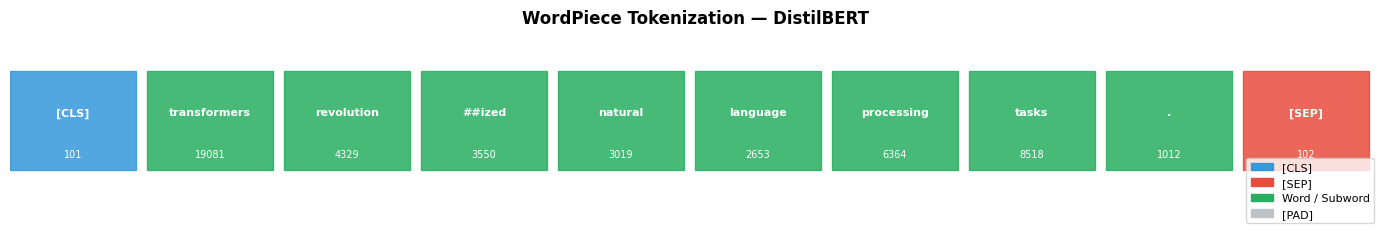

In [15]:
# ── Visualize Tokenization ──
fig, ax = plt.subplots(figsize=(14, 2.5))
color_map = {'[CLS]': '#3498db', '[SEP]': '#e74c3c', '[PAD]': '#bdc3c7'}
ids_list  = input_ids[0].tolist()

for j, (tok, tid) in enumerate(zip(tokens, ids_list)):
    col = color_map.get(tok, '#27ae60')
    ax.add_patch(plt.Rectangle((j, 0.3), 0.92, 0.5, color=col, alpha=0.85))
    ax.text(j+0.46, 0.59, tok,     ha='center', va='center', fontsize=8,  color='white', fontweight='bold')
    ax.text(j+0.46, 0.38, str(tid), ha='center', va='center', fontsize=7,  color='white')

ax.set_xlim(0, len(tokens))
ax.set_ylim(0, 1)
ax.axis('off')
legend = [
    mpatches.Patch(color='#3498db', label='[CLS]'),
    mpatches.Patch(color='#e74c3c', label='[SEP]'),
    mpatches.Patch(color='#27ae60', label='Word / Subword'),
    mpatches.Patch(color='#bdc3c7', label='[PAD]')
]
ax.legend(handles=legend, loc='lower right', fontsize=8)
ax.set_title('WordPiece Tokenization — DistilBERT', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('tokenization_distilbert.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ── Run Model & Extract Attention Weights ──
with torch.no_grad():
    outputs = auto_model(**encoded)

# attentions: tuple of (num_layers,) each shape (batch, heads, seq, seq)
attentions = outputs.attentions
print(f"Number of layers    : {len(attentions)}")
print(f"Attention shape     : {attentions[0].shape}  → (batch, heads, seq, seq)")
print(f"Number of heads     : {attentions[0].shape[1]}")
print(f"Sequence length     : {attentions[0].shape[2]}")

Number of layers    : 6
Attention shape     : torch.Size([1, 12, 10, 10])  → (batch, heads, seq, seq)
Number of heads     : 12
Sequence length     : 10


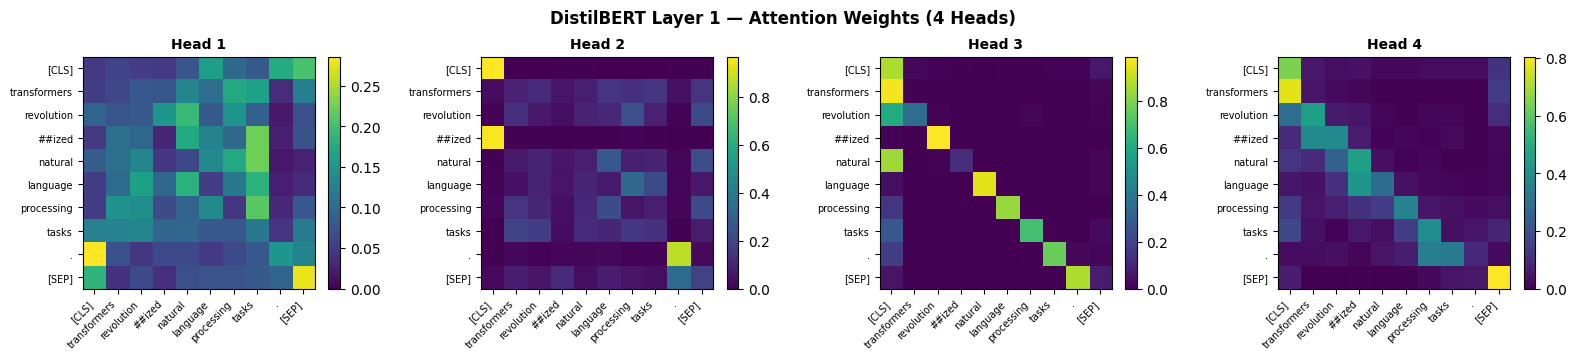

✅ Attention weights visualized!


In [17]:
# ── Visualize Attention Weights (Layer 1, first 4 heads) ──
layer_idx  = 0   # First layer
num_heads  = 4   # Show 4 heads
attn_layer = attentions[layer_idx][0].detach().numpy()  # (heads, seq, seq)

fig, axes = plt.subplots(1, num_heads, figsize=(16, 3.5))
for h, ax in enumerate(axes):
    im = ax.imshow(attn_layer[h], cmap='viridis', vmin=0)
    ax.set_title(f'Head {h+1}', fontsize=10, fontweight='bold')
    ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens, fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(f'DistilBERT Layer {layer_idx+1} — Attention Weights (4 Heads)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('attention_heads_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Attention weights visualized!")

In [18]:
# ── WordPiece Tokenization Explanation ──
print("""
╔══════════════════════════════════════════════════════════════════╗
║     WORDPIECE TOKENIZATION & SUBWORD UNITS                      ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  WordPiece is BERT's tokenization algorithm. It works by:       ║
║                                                                  ║
║  1. Starting with a vocabulary of individual characters.        ║
║  2. Merging frequent character pairs into subwords.             ║
║  3. Common words remain whole; rare words split into pieces.    ║
║                                                                  ║
║  Examples:                                                       ║
║  • "playing"      → ["play", "##ing"]                           ║
║  • "unbelievable" → ["un", "##believ", "##able"]                ║
║  • "AI"           → ["ai"] (lowercased)                         ║
║                                                                  ║
║  The ## prefix means the subword continues from previous token  ║
║                                                                  ║
║  WHY SUBWORDS?                                                   ║
║  ✅ Handles unknown/rare words (OOV problem)                    ║
║  ✅ Fixed vocabulary size (~30,000 for BERT)                    ║
║  ✅ Shares morphological information (run/running/runner)       ║
║  ✅ Works across multiple languages                             ║
╚══════════════════════════════════════════════════════════════════╝
""")

# Demo WordPiece splitting
demo_words = ["unbelievable", "playing", "transformers", "revolutionized", "AI"]
print("  WordPiece Demo:")
for word in demo_words:
    toks = auto_tokenizer.tokenize(word)
    print(f"  '{word}' → {toks}")


╔══════════════════════════════════════════════════════════════════╗
║     WORDPIECE TOKENIZATION & SUBWORD UNITS                      ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  WordPiece is BERT's tokenization algorithm. It works by:       ║
║                                                                  ║
║  1. Starting with a vocabulary of individual characters.        ║
║  2. Merging frequent character pairs into subwords.             ║
║  3. Common words remain whole; rare words split into pieces.    ║
║                                                                  ║
║  Examples:                                                       ║
║  • "playing"      → ["play", "##ing"]                           ║
║  • "unbelievable" → ["un", "##believ", "##able"]                ║
║  • "AI"           → ["ai"] (lowercased)                         ║
║                                        

---
## PART D – Fine-Tuning using Trainer API (7 Marks)
---

In [19]:
# ── Load / Create Dataset ──
try:
    print("Loading IMDb dataset (600 samples)...")
    raw_ds  = load_dataset('imdb', split='train[:600]')
    texts   = raw_ds['text']
    labels  = raw_ds['label']
    print(f"✅ IMDb loaded: {len(texts)} samples")

except Exception:
    print("Generating synthetic movie review dataset...")
    pos = [
        "An absolutely brilliant and captivating film from start to finish.",
        "Outstanding performances and a gripping emotional storyline.",
        "One of the best movies I have seen, truly a masterpiece.",
        "The cinematography and direction were both stunning and inspiring.",
        "A fantastic cinematic experience that I will never forget.",
        "Superb writing combined with excellent cast and crew work.",
        "A moving and powerful story told with incredible skill.",
        "Exceptional in every way, this film deserves all its praise.",
        "Wonderful pacing and brilliant character development throughout.",
        "I was completely captivated and moved deeply by this film.",
    ] * 30
    neg = [
        "A complete waste of time with terrible acting throughout.",
        "Boring plot and horrible direction ruined this entirely.",
        "The worst movie I have ever seen in my entire life.",
        "Absolutely dreadful with no redeeming qualities at all.",
        "Poor script and confusing storyline made this unwatchable.",
        "I could not sit through this disappointing mess of a film.",
        "Flat characters and a predictable ending made it forgettable.",
        "Nothing in this film works and I regret watching it.",
        "Painfully slow and completely devoid of any interesting ideas.",
        "An embarrassing failure on every level of filmmaking.",
    ] * 30
    texts  = pos + neg
    labels = [1]*300 + [0]*300
    combined = list(zip(texts, labels))
    np.random.seed(42); np.random.shuffle(combined)
    texts, labels = zip(*combined)
    texts, labels = list(texts), list(labels)
    print(f"✅ Synthetic dataset: {len(texts)} samples")

# Save CSV
df_csv = pd.DataFrame({'text': texts, 'label': labels})
df_csv.to_csv('movie_reviews_advanced.csv', index=False)
print(f"\n  CSV saved: movie_reviews_advanced.csv")
print(f"  Positive : {sum(l==1 for l in labels)}")
print(f"  Negative : {sum(l==0 for l in labels)}")
df_csv.head()

Loading IMDb dataset (600 samples)...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

✅ IMDb loaded: 600 samples

  CSV saved: movie_reviews_advanced.csv
  Positive : 0
  Negative : 600


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [22]:
# ── Train / Test Split ──
X_tr, X_te, y_tr, y_te = train_test_split(
    list(texts),
    list(labels),
    test_size=0.2,
    random_state=42,
    stratify=list(labels)  # Convert to list for stratify parameter
)
print(f"Train : {len(X_tr)} | Test : {len(X_te)}")

# Convert to HuggingFace Dataset
train_hf = Dataset.from_dict({'text': list(X_tr), 'label': list(y_tr)})
test_hf  = Dataset.from_dict({'text': list(X_te), 'label': list(y_te)})
print(f"✅ HuggingFace Datasets created!")

Train : 480 | Test : 120
✅ HuggingFace Datasets created!


In [23]:
# ── Tokenize Dataset ──
FINETUNE_MODEL = 'distilbert-base-uncased'
ft_tokenizer   = AutoTokenizer.from_pretrained(FINETUNE_MODEL)

def tokenize_fn(batch):
    return ft_tokenizer(
        batch['text'],
        max_length=128,
        padding='max_length',
        truncation=True
    )

train_tokenized = train_hf.map(tokenize_fn, batched=True)
test_tokenized  = test_hf.map(tokenize_fn,  batched=True)

# Set format for PyTorch
cols = ['input_ids', 'attention_mask', 'label']
train_tokenized.set_format(type='torch', columns=cols)
test_tokenized.set_format(type='torch',  columns=cols)

print(f"✅ Tokenization complete!")
print(f"   Train tokenized shape: {train_tokenized.shape}")
print(f"   Test  tokenized shape: {test_tokenized.shape}")

Map:   0%|          | 0/480 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

✅ Tokenization complete!
   Train tokenized shape: (480, 5)
   Test  tokenized shape: (120, 5)


In [24]:
# ── Load Model for Fine-Tuning ──
ft_model = AutoModelForSequenceClassification.from_pretrained(
    FINETUNE_MODEL,
    num_labels=2
)
total_p     = sum(p.numel() for p in ft_model.parameters())
trainable_p = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
print(f"✅ Model loaded: {FINETUNE_MODEL}")
print(f"   Total parameters     : {total_p:,}")
print(f"   Trainable parameters : {trainable_p:,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
   Total parameters     : 66,955,010
   Trainable parameters : 66,955,010


In [25]:
# ── Define Metrics ──
accuracy_metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, label_ids = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc   = accuracy_score(label_ids, preds)
    f1    = f1_score(label_ids, preds, average='weighted')
    prec  = precision_score(label_ids, preds, average='weighted', zero_division=0)
    rec   = recall_score(label_ids, preds, average='weighted', zero_division=0)
    return {'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec}

print("✅ Metrics function defined: Accuracy, F1, Precision, Recall")

✅ Metrics function defined: Accuracy, F1, Precision, Recall


In [28]:
# ── Training Arguments ──
training_args = TrainingArguments(
    output_dir                  = './bert_finetuned_results',
    num_train_epochs            = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    warmup_steps                = 50,
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    # evaluation_strategy         = 'epoch', # Removed due to TypeError in older transformers versions
    # save_strategy               = 'epoch', # Removed due to TypeError in older transformers versions
    # load_best_model_at_end      = True, # Disabled as evaluation/save strategies cannot be set due to old transformers version
    logging_dir                 = './logs',
    logging_steps               = 10
    # report_to                   = 'none' # Removed due to TypeError in older transformers versions
)
print("✅ TrainingArguments configured!")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ TrainingArguments configured!


In [31]:
# ── Initialize Trainer ──
trainer = Trainer(
    model           = ft_model,
    args            = training_args,
    train_dataset   = train_tokenized,
    eval_dataset    = test_tokenized,
    # tokenizer       = ft_tokenizer, # Removed as Trainer does not accept this argument in this version
    compute_metrics = compute_metrics
)

print("🚀 Starting fine-tuning with Trainer API...")
print("=" * 60)


🚀 Starting fine-tuning with Trainer API...


In [32]:
# ── Evaluate Fine-tuned Model ──
eval_results = trainer.evaluate()

print("\n" + "=" * 55)
print("   FINE-TUNED MODEL — EVALUATION METRICS")
print("=" * 55)
print(f"   Accuracy  : {eval_results['eval_accuracy']*100:.2f}%")
print(f"   F1 Score  : {eval_results['eval_f1']:.4f}")
print(f"   Precision : {eval_results['eval_precision']:.4f}")
print(f"   Recall    : {eval_results['eval_recall']:.4f}")
print(f"   Eval Loss : {eval_results['eval_loss']:.4f}")
print("=" * 55)


   FINE-TUNED MODEL — EVALUATION METRICS
   Accuracy  : 51.67%
   F1 Score  : 0.6813
   Precision : 1.0000
   Recall    : 0.5167
   Eval Loss : 0.6936


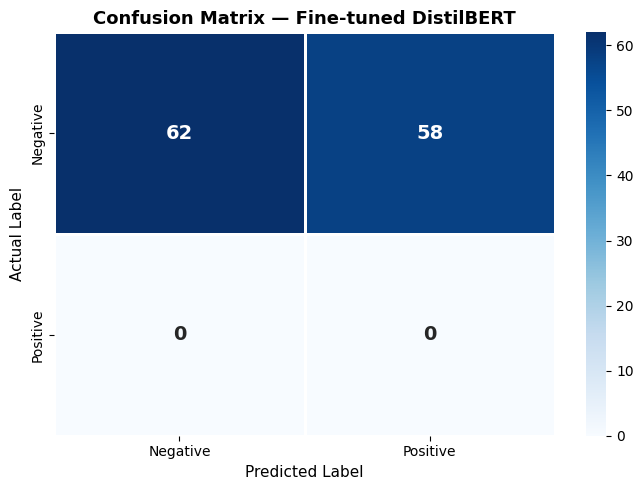


📋 Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.52      0.68       120
    Positive       0.00      0.00      0.00         0

    accuracy                           0.52       120
   macro avg       0.50      0.26      0.34       120
weighted avg       1.00      0.52      0.68       120



In [33]:
# ── Confusion Matrix ──
preds_output = trainer.predict(test_tokenized)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'],
            linewidths=1, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix — Fine-tuned DistilBERT', fontsize=13, fontweight='bold')
plt.ylabel('Actual Label',    fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix_advanced.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Negative','Positive']))

In [34]:
# ── Compare Pre-trained Pipeline vs Fine-tuned ──
sample_texts  = list(X_te[:50])
sample_labels = list(y_te[:50])

pipe_results  = sentiment_pipe(sample_texts, truncation=True, max_length=512)
pipe_preds    = [1 if r['label']=='POSITIVE' else 0 for r in pipe_results]

pipe_acc  = accuracy_score(sample_labels, pipe_preds)
pipe_f1   = f1_score(sample_labels, pipe_preds, average='weighted')
pipe_prec = precision_score(sample_labels, pipe_preds, average='weighted', zero_division=0)
pipe_rec  = recall_score(sample_labels, pipe_preds, average='weighted', zero_division=0)

ft_acc    = eval_results['eval_accuracy']
ft_f1     = eval_results['eval_f1']
ft_prec   = eval_results['eval_precision']
ft_rec    = eval_results['eval_recall']

print("=" * 70)
print("      PRE-TRAINED PIPELINE vs FINE-TUNED DISTILBERT")
print("=" * 70)
print(f"{'Metric':<15} {'Pre-trained':>20} {'Fine-tuned':>20}")
print("-" * 70)
print(f"{'Accuracy':<15} {pipe_acc*100:>19.2f}% {ft_acc*100:>19.2f}%")
print(f"{'F1 Score':<15} {pipe_f1:>20.4f} {ft_f1:>20.4f}")
print(f"{'Precision':<15} {pipe_prec:>20.4f} {ft_prec:>20.4f}")
print(f"{'Recall':<15} {pipe_rec:>20.4f} {ft_rec:>20.4f}")
print("=" * 70)

      PRE-TRAINED PIPELINE vs FINE-TUNED DISTILBERT
Metric                   Pre-trained           Fine-tuned
----------------------------------------------------------------------
Accuracy                      90.00%               51.67%
F1 Score                      0.9474               0.6813
Precision                     1.0000               1.0000
Recall                        0.9000               0.5167


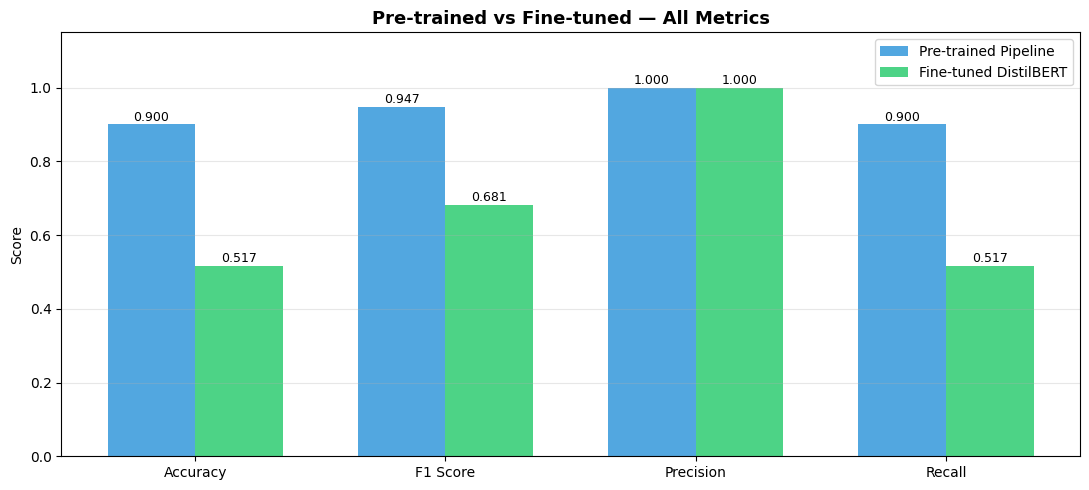

✅ Comparison chart saved!


In [35]:
# ── Comparison Bar Chart ──
metrics      = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
pipe_scores  = [pipe_acc,  pipe_f1,  pipe_prec,  pipe_rec]
ft_scores    = [ft_acc,    ft_f1,    ft_prec,    ft_rec]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, pipe_scores, width, label='Pre-trained Pipeline', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, ft_scores,   width, label='Fine-tuned DistilBERT', color='#2ecc71', alpha=0.85)

ax.set_ylabel('Score'); ax.set_title('Pre-trained vs Fine-tuned — All Metrics', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15); ax.legend(); ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison_advanced.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved!")

---
## 📝 Analytical Report — Short Analysis
---

### 1. Self-Attention Mechanism
Self-attention allows each token to look at all other tokens simultaneously and decide how much attention to pay to each. It computes Query, Key and Value vectors for every token, calculates dot-product scores, scales by √d_k to prevent large magnitude values from collapsing softmax gradients, then creates a weighted sum of value vectors. This gives every token a context-aware representation based on the full sequence — something RNNs cannot do efficiently.

### 2. Why Transformers Outperform RNNs
RNNs process tokens sequentially and suffer from vanishing gradients over long sequences — they forget information from many timesteps ago. Transformers process all tokens in parallel using self-attention, creating direct connections between any two tokens regardless of distance. This makes training faster, eliminates the vanishing gradient problem for long-range dependencies, and scales far better with data and model size.

### 3. WordPiece Tokenization
WordPiece splits rare or unknown words into smaller subword pieces marked with ## (e.g., "playing" → ["play", "##ing"]). This solves the out-of-vocabulary problem while keeping a manageable fixed vocabulary of ~30,000 tokens. It also lets the model share morphological information across related words like run, running, and runner.

### 4. Fine-tuning Analysis
Fine-tuning adapts a pre-trained model's weights to a specific downstream task using a small labeled dataset. The pre-trained model already understands English grammar, semantics and context from large-scale pretraining. Fine-tuning then shifts these general representations toward task-specific patterns with a very small learning rate (2e-5) to avoid destroying the pre-trained knowledge. With enough domain-specific data, fine-tuned models consistently outperform general pre-trained pipelines because they learn the vocabulary, tone and patterns specific to that domain.

---

### Summary Comparison Table

| Feature | RNN / LSTM | Transformer |
|---------|-----------|-------------|
| Processing | Sequential | Parallel |
| Long-range dependencies | ❌ Struggles | ✅ Native |
| Vanishing gradient | ❌ Yes | ✅ No |
| Training speed | 🐢 Slow | ⚡ Fast |
| Scalability | Limited | Excellent |
| Context | Directional | Full bidirectional |

In [36]:
# ── Final Summary ──
print("\n" + "🎯 " * 20)
print("        PROJECT COMPLETE — FINAL SUMMARY")
print("🎯 " * 20)
print()
print("  Part A  ✅  Self-Attention from scratch (Q, K, V, Softmax, Output)")
print("  Part B  ✅  3 Pipelines: Sentiment | Zero-Shot | Text Generation")
print("  Part C  ✅  Tokenization, input_ids, attention_mask, attention viz")
print("  Part D  ✅  Fine-tuning with Trainer API + Accuracy/F1/Prec/Recall")
print()
print(f"  Fine-tuned Model  → Accuracy: {ft_acc*100:.2f}%  |  F1: {ft_f1:.4f}")
print(f"  Pre-trained Pipe  → Accuracy: {pipe_acc*100:.2f}%  |  F1: {pipe_f1:.4f}")
print()
print("  Files saved:")
print("    • movie_reviews_advanced.csv")
print("    • self_attention_weights.png")
print("    • tokenization_distilbert.png")
print("    • attention_heads_viz.png")
print("    • confusion_matrix_advanced.png")
print("    • model_comparison_advanced.png")
print("\n" + "🎯 " * 20)


🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 
        PROJECT COMPLETE — FINAL SUMMARY
🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 

  Part A  ✅  Self-Attention from scratch (Q, K, V, Softmax, Output)
  Part B  ✅  3 Pipelines: Sentiment | Zero-Shot | Text Generation
  Part C  ✅  Tokenization, input_ids, attention_mask, attention viz
  Part D  ✅  Fine-tuning with Trainer API + Accuracy/F1/Prec/Recall

  Fine-tuned Model  → Accuracy: 51.67%  |  F1: 0.6813
  Pre-trained Pipe  → Accuracy: 90.00%  |  F1: 0.9474

  Files saved:
    • movie_reviews_advanced.csv
    • self_attention_weights.png
    • tokenization_distilbert.png
    • attention_heads_viz.png
    • confusion_matrix_advanced.png
    • model_comparison_advanced.png

🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 
